In [1]:
from datetime import datetime
import socket

start = datetime.now()
print(f"Start time: {start}")
print(f"Host name: {socket.gethostname()}")

Start time: 2025-12-18 12:09:52.092145
Host name: nid007026


# Generate and Visualize Augmented Datasets

This notebook
- calls the CLI script `scripts-lm/augmentation.py` to generate the five augmentation variants (rotation, scaling, sheering, translation, deformation), and
- visualizes the effect of each augmentation on a selected sample from the raw training data.


In [2]:
# Environment and path setup
from pathlib import Path
import sys

# Assume this notebook lives in notebooks-lm under the project root
current_dir = Path.cwd()
BASE_PATH = current_dir.parent

SRC_PATH = BASE_PATH / 'src'
SCRIPTS_PATH = BASE_PATH / 'scripts-lm'
RAW_DATA_PATH = BASE_PATH / 'data' / 'raw'
AUGMENTED_DATA_PATH = BASE_PATH / 'data' / 'augmented'

# Ensure src on sys.path (if we want to reuse project utilities later)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print(f"Base path: {BASE_PATH}")
print(f"Scripts path: {SCRIPTS_PATH}")
print(f"Raw data path: {RAW_DATA_PATH}")
print(f"Augmented data path: {AUGMENTED_DATA_PATH}")


Base path: /users/lmantel/lab
Scripts path: /users/lmantel/lab/scripts-lm
Raw data path: /users/lmantel/lab/data/raw
Augmented data path: /users/lmantel/lab/data/augmented


In [3]:
# Imports for running the augmentation script and visualization
import subprocess
import gzip
import pickle

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Reuse helper for gzipped pickle IO

def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object


def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)


In [4]:
# Configuration for augmentation generation

AUGMENTATION_CONFIGS = [
    {"strategy": "deformation", "output": AUGMENTED_DATA_PATH / "train-deformation.pkl"}, # first because slowest
    {"strategy": "rotation",    "output": AUGMENTED_DATA_PATH / "train-rotation.pkl"},
    {"strategy": "scaling",     "output": AUGMENTED_DATA_PATH / "train-scaling.pkl"},
    {"strategy": "sheering",    "output": AUGMENTED_DATA_PATH / "train-sheering.pkl"},
    {"strategy": "translation", "output": AUGMENTED_DATA_PATH / "train-translation.pkl"},
]

NUM_AUGMENTATIONS_PER_SAMPLE = 1
SEED = 42

print("Augmentation configs:")
for cfg in AUGMENTATION_CONFIGS:
    print(f"  - {cfg['strategy']}: {cfg['output']}")


Augmentation configs:
  - deformation: /users/lmantel/lab/data/augmented/train-deformation.pkl
  - rotation: /users/lmantel/lab/data/augmented/train-rotation.pkl
  - scaling: /users/lmantel/lab/data/augmented/train-scaling.pkl
  - sheering: /users/lmantel/lab/data/augmented/train-sheering.pkl
  - translation: /users/lmantel/lab/data/augmented/train-translation.pkl


In [5]:
# Run scripts-lm/augmentation.py for all configured strategies (optionally in parallel)

from concurrent.futures import ThreadPoolExecutor, as_completed

AUGMENT_SCRIPT = SCRIPTS_PATH / "augmentation.py"
OVERWRITE_EXISTING = True
DRY_RUN = False

if not AUGMENT_SCRIPT.exists():
    raise FileNotFoundError(f"Augmentation script not found: {AUGMENT_SCRIPT}")


def run_augmentation_script(strategy: str, output_path: Path, num_augmentations: int = 1, seed: int = 42, dry_run: bool = False):
    """Call the CLI augmentation script with the given configuration.

    This uses the current Python executable (sys.executable) to ensure the
    same environment/venv is used as for this notebook.
    """
    cmd = [
        sys.executable,
        str(AUGMENT_SCRIPT),
        "--strategy", strategy,
        "--output", str(output_path),
        "--num-augmentations", str(num_augmentations),
        "--seed", str(seed),
    ]
    if dry_run:
        cmd.append("--dry-run")
    print(f"\nRunning: {' '.join(cmd)}")
    result = subprocess.run(cmd, cwd=str(BASE_PATH))
    if result.returncode != 0:
        raise RuntimeError(f"Augmentation script failed for strategy={strategy} (exit code {result.returncode})")

def run_cfg(cfg, overwrite_existing=OVERWRITE_EXISTING, dry_run=DRY_RUN):
    """Wrapper to run one augmentation config and report status."""
    strategy = cfg["strategy"]
    output_path = cfg["output"]

    if dry_run:
        print(f"Dry run: would run augmentation for {strategy}, output to {output_path}")
        return strategy, "dry-run"

    if not overwrite_existing and output_path.exists():
        print(f"Skipping {strategy}: {output_path} already exists")
        return strategy, "skipped"
    try:
        run_augmentation_script(
            strategy=strategy,
            output_path=output_path,
            num_augmentations=NUM_AUGMENTATIONS_PER_SAMPLE,
            seed=SEED,
        )
        return strategy, "ok"
    except Exception as e:
        return strategy, f"error: {e}"

# Limit parallelism so GPU/RAM are not overloaded
MAX_WORKERS = 3  # ggf. auf 3 erhöhen, wenn Node-Ressourcen es hergeben

print(f"Running augmentations with up to {MAX_WORKERS} workers...")
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_cfg, cfg) for cfg in AUGMENTATION_CONFIGS]
    for fut in as_completed(futures):
        strategy, status = fut.result()
        print(f"Strategy {strategy}: {status}")

Running augmentations with up to 3 workers...

Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy deformation --output /users/lmantel/lab/data/augmented/train-deformation.pkl --num-augmentations 1 --seed 42

Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy rotation --output /users/lmantel/lab/data/augmented/train-rotation.pkl --num-augmentations 1 --seed 42

Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy scaling --output /users/lmantel/lab/data/augmented/train-scaling.pkl --num-augmentations 1 --seed 42
Base path: /users/lmantel/lab
Input path: /users/lmantel/lab/data/raw/train.pkl
Output path: /users/lmantel/lab/data/augmented/train-scaling.pkl
Strategy: scaling
Num augmentations per sample: 1
Seed: 42
Using device: cuda
Dry run: False

Loading training data from /users/lmantel/lab/data/raw/train.pkl ...
Base path: /users/lmante

Augment deformation: 100%|██████████| 65/65 [00:17<00:00,  3.69it/s]


Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data to /users/lmantel/lab/data/augmented/train-deformation.pkl ...


Augment rotation: 100%|██████████| 65/65 [00:24<00:00,  2.60it/s]


Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data to /users/lmantel/lab/data/augmented/train-rotation.pkl ...


...


Running: /users/lmantel/lab/.venv/bin/python /users/lmantel/lab/scripts-lm/augmentation.py --strategy translation --output /users/lmantel/lab/data/augmented/train-translation.pkl --num-augmentations 1 --seed 42
Strategy rotation: ok
Done.
Strategy scaling: ok
Base path: /users/lmantel/lab
Input path: /users/lmantel/lab/data/raw/train.pkl
Output path: /users/lmantel/lab/data/augmented/train-translation.pkl
Strategy: translation
Num augmentations per sample: 1
Seed: 42
Using device: cuda
Dry run: False

Loading training data from /users/lmantel/lab/data/raw/train.pkl ...
Loaded 65 samples.
Generating 1 augmented samples per original (65 augmented samples in total)...


Augment sheering: 100%|██████████| 65/65 [00:24<00:00,  2.69it/s]/s]


Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data to /users/lmantel/lab/data/augmented/train-sheering.pkl ...


Augment translation: 100%|██████████| 65/65 [00:23<00:00,  2.74it/s]


Final augmented dataset size: 65 (augmented only, originals not included)
Saving augmented data to /users/lmantel/lab/data/augmented/train-translation.pkl ...
Done.
Strategy sheering: ok
Done.
Strategy translation: ok


In [6]:
# # Run scripts-lm/augmentation.py for all configured strategies

# from pathlib import Path
# import sys

# AUGMENT_SCRIPT = SCRIPTS_PATH / "augmentation.py"
# OVERWRITE_EXISTING = True
# DRY_RUN = False

# if not AUGMENT_SCRIPT.exists():
#     raise FileNotFoundError(f"Augmentation script not found: {AUGMENT_SCRIPT}")


# def run_augmentation_script(strategy: str, output_path: Path, num_augmentations: int = 1, seed: int = 42, dry_run: bool = False):
#     """Call the CLI augmentation script with the given configuration.

#     This uses the current Python executable (sys.executable) to ensure the
#     same environment/venv is used as for this notebook.
#     """
#     cmd = [
#         sys.executable,
#         str(AUGMENT_SCRIPT),
#         "--strategy", strategy,
#         "--output", str(output_path),
#         "--num-augmentations", str(num_augmentations),
#         "--seed", str(seed),
#     ]
#     if dry_run:
#         cmd.append("--dry-run")
#     print(f"\nRunning: {' '.join(cmd)}")
#     result = subprocess.run(cmd, cwd=str(BASE_PATH))
#     if result.returncode != 0:
#         raise RuntimeError(f"Augmentation script failed for strategy={strategy} (exit code {result.returncode})")

# for cfg in AUGMENTATION_CONFIGS:
#     strategy = cfg["strategy"]
#     output_path = cfg["output"]
#     if not OVERWRITE_EXISTING and output_path.exists():
#         print(f"Skipping {strategy}: {output_path} already exists")
#         continue
#     run_augmentation_script(
#         strategy=strategy,
#         output_path=output_path,
#         num_augmentations=NUM_AUGMENTATIONS_PER_SAMPLE,
#         seed=SEED,
#         dry_run=DRY_RUN,
#     )

# print("\nAll requested augmentations are available.")


In [7]:
# Load raw data and one example sample

raw_train_path = RAW_DATA_PATH / 'train.pkl'
raw_data = load_zipped_pickle(str(raw_train_path))
print(f"Loaded raw training data: {len(raw_data)} samples")

# Pick one example sample for visualization (you can change the index)
EXAMPLE_INDEX = 0
example_sample = raw_data[EXAMPLE_INDEX]
example_name = example_sample.get('name')
print(f"Using example sample index {EXAMPLE_INDEX} with name: {example_name}")

video = example_sample['video']  # (H, W, T)
label = example_sample['label']  # (H, W, T)
box = example_sample['box']  # (H, W)
H, W, T = video.shape
mid_t = example_sample['frames'][len(example_sample['frames']) // 2] if example_sample.get('frames') else T // 2
print(f"Middle frame index for visualization: {mid_t}")


Loaded raw training data: 65 samples
Using example sample index 0 with name: D47OR19ANJ
Middle frame index for visualization: 59


In [8]:
# Load one matching augmented sample per strategy for the chosen example

augmented_examples = {}

for cfg in AUGMENTATION_CONFIGS:
    strategy = cfg["strategy"]
    path = cfg["output"]
    data = load_zipped_pickle(str(path))
    print(f"Loaded {len(data)} augmented samples for {strategy} from {path}")

    # Find first augmented sample that corresponds to the chosen example (by base name prefix)
    target_prefix = f"{example_name}_{strategy}_"
    match = None
    for s in data:
        name = s.get('name', '')
        if name.startswith(target_prefix):
            match = s
            break
    if match is None:
        print(f"  WARNING: No augmented sample found for {example_name} with strategy {strategy}")
    else:
        augmented_examples[strategy] = match
        print(f"  -> Using augmented sample: {match.get('name')}")


Loaded 65 augmented samples for deformation from /users/lmantel/lab/data/augmented/train-deformation.pkl
  -> Using augmented sample: D47OR19ANJ_deformation_aug1
Loaded 65 augmented samples for rotation from /users/lmantel/lab/data/augmented/train-rotation.pkl
  -> Using augmented sample: D47OR19ANJ_rotation_aug1
Loaded 65 augmented samples for scaling from /users/lmantel/lab/data/augmented/train-scaling.pkl
  -> Using augmented sample: D47OR19ANJ_scaling_aug1
Loaded 65 augmented samples for sheering from /users/lmantel/lab/data/augmented/train-sheering.pkl
  -> Using augmented sample: D47OR19ANJ_sheering_aug1
Loaded 65 augmented samples for translation from /users/lmantel/lab/data/augmented/train-translation.pkl
  -> Using augmented sample: D47OR19ANJ_translation_aug1


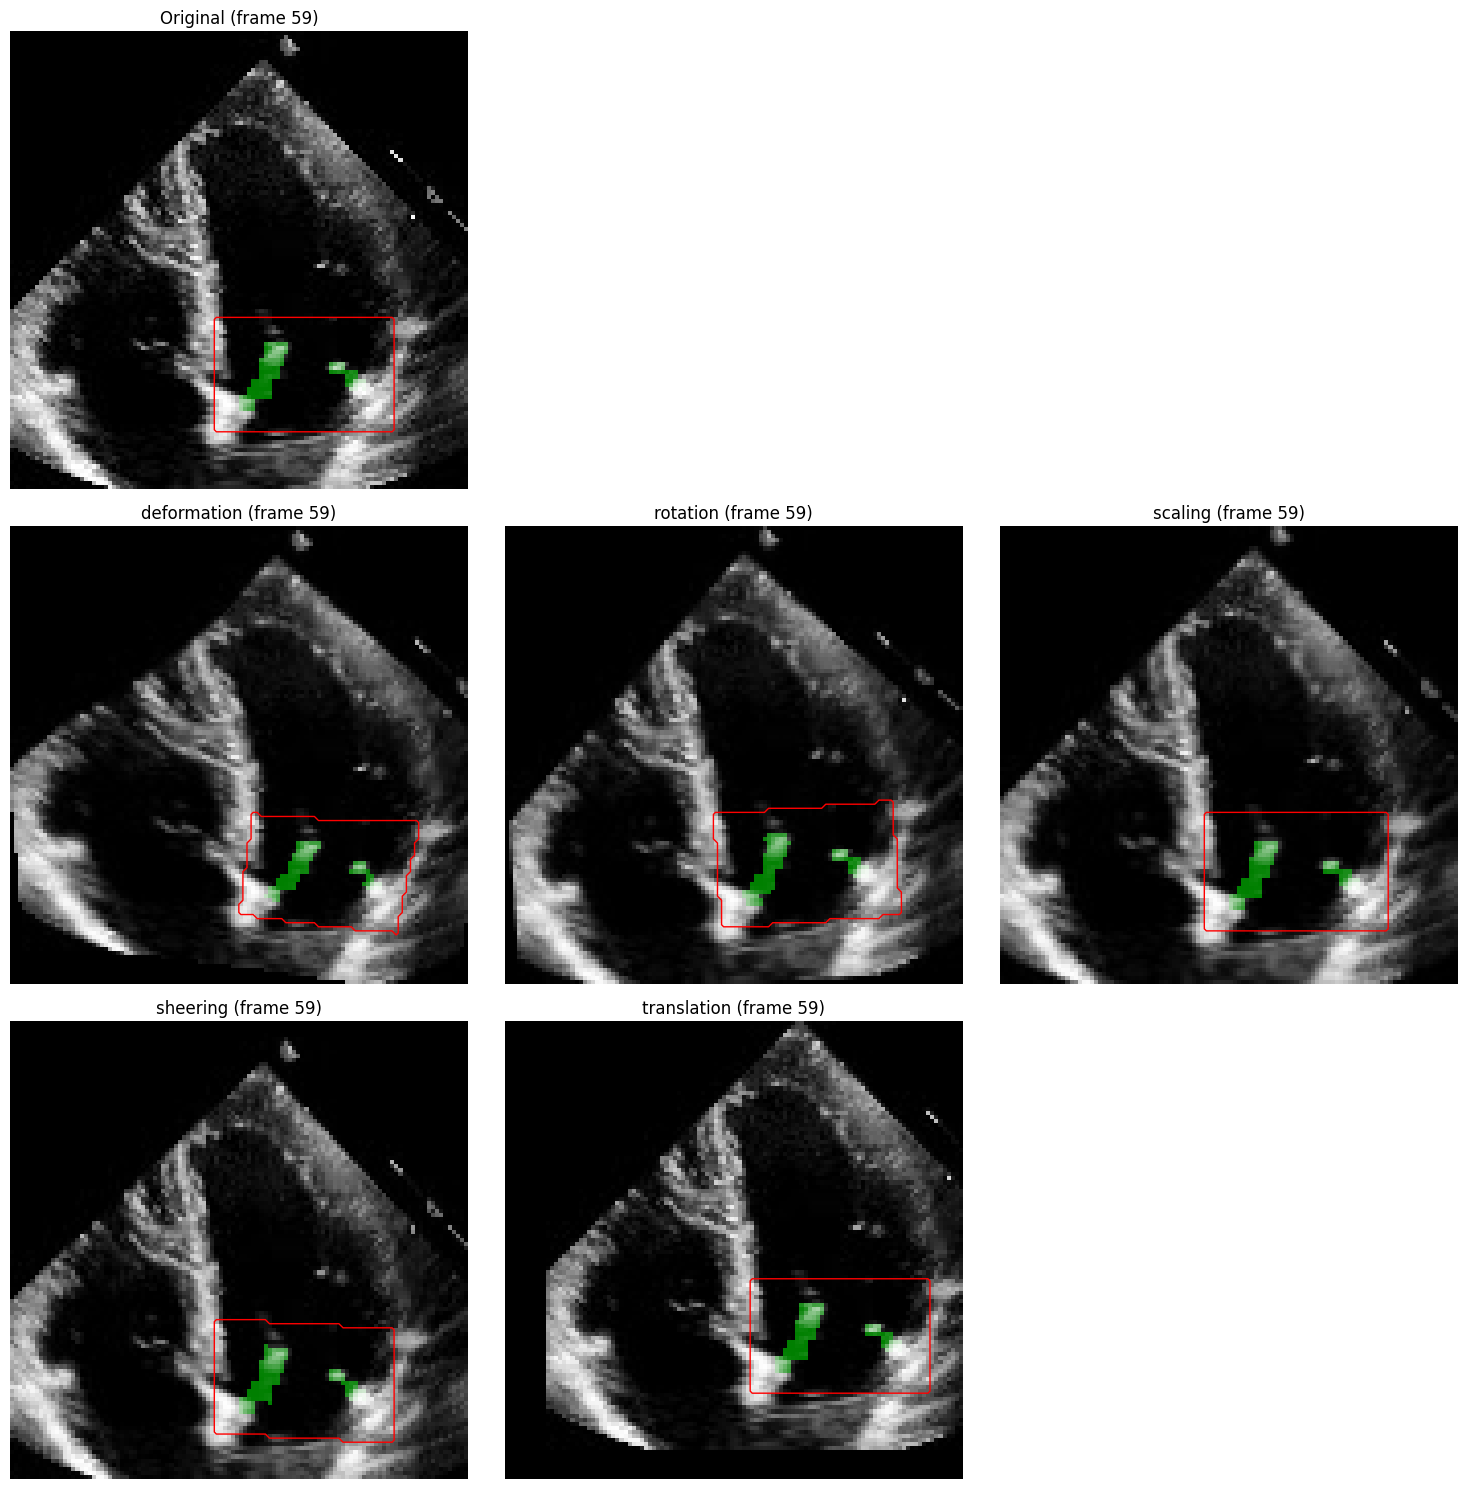

In [9]:
# Visualize original and all augmentations (single frame per sample, with box)

strategies_to_show = [cfg["strategy"] for cfg in AUGMENTATION_CONFIGS]

# Prepare original data
orig_frame = video[:, :, mid_t]
orig_mask = label[:, :, mid_t]
orig_box = box  # (H, W)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

def plot_overlay(ax, frame, mask, box_mask, title: str):
    """Plot overlay of frame + label mask + box (as red contour)."""
    overlay = np.stack([frame, frame, frame], axis=-1).astype(np.float32)
    # Green channel for label mask
    overlay[..., 1] = np.where(
        mask,
        overlay[..., 1] * 0.5 + 255 * 0.5,
        overlay[..., 1],
    )
    ax.imshow(overlay.astype(np.uint8))
    # Red contour for box
    if box_mask is not None:
        ax.contour(box_mask, colors='red', linewidths=1)
    ax.set_title(title)
    ax.axis('off')

# Row 0, Col 0: original overlay
plot_overlay(axes[0, 0], orig_frame, orig_mask, orig_box, f"Original (frame {mid_t})")

# Hide remaining cells in first row (optional)
axes[0, 1].axis('off')
axes[0, 2].axis('off')

# Rows 1-2: all augmentations (some cells may remain empty if fewer than 6)
for idx, strategy in enumerate(strategies_to_show):
    row = 1 + idx // 3
    col = idx % 3
    ax = axes[row, col]

    aug_sample = augmented_examples.get(strategy)
    if aug_sample is None:
        ax.set_title(f"{strategy}: not found")
        ax.axis('off')
        continue

    aug_video = aug_sample['video']
    aug_label = aug_sample['label']
    aug_box = aug_sample.get('box', None)

    H_a, W_a, T_a = aug_video.shape
    # Try to use a frame index consistent with original if possible
    t_idx = mid_t if mid_t < T_a else T_a // 2

    frame_a = aug_video[:, :, t_idx]
    mask_a = aug_label[:, :, t_idx]

    plot_overlay(ax, frame_a, mask_a, aug_box, f"{strategy} (frame {t_idx})")

# Hide any unused cells (if fewer than 6 augmentations)
for idx in range(len(strategies_to_show), 6):
    row = 1 + idx // 3
    col = idx % 3
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [10]:
end = datetime.now()
print(f"End time: {end}")
print(f"Duration: {end - start}")
print(f"Host name: {socket.gethostname()}")

End time: 2025-12-18 12:14:15.261198
Duration: 0:04:23.169053
Host name: nid007026
